# 📊 ReviewSense AI – Exploratory Data Analysis

This notebook explores the Amazon Fine Food Reviews dataset to understand its structure, quality, and characteristics before building the NLP pipeline for ReviewSense AI.

The insights obtained from this analysis will guide preprocessing decisions for review summarization, sentiment analysis, aspect extraction, and buying recommendation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv('../data/Reviews.csv')

In [6]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [8]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 43.4 MB


## Dataset Summary

- Total Reviews: **568,454**
- Features: **10**
- Dataset Size: **43.4 MB**

The dataset is sufficiently large for training and evaluating Transformer-based NLP models while remaining small enough to process comfortably on a local machine.

In [12]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

## Data Quality Assessment

The dataset is highly complete.

Only two columns contain missing values:

- ProfileName → 26 missing values
- Summary → 27 missing values

Considering the dataset contains over **568k reviews**, the missing data is negligible and is unlikely to significantly impact downstream NLP tasks.

In [13]:
df.shape

(568454, 10)

In [14]:
df["Score"].value_counts()

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.duplicated(subset=["Text"]).sum()

np.int64(174875)

In [17]:
df[df.duplicated(subset=["Text"], keep=False)].head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
10,11,B0001PB9FE,A3HDKO7OW0QNK4,Canadian Fan,1,1,5,1107820800,The Best Hot Sauce in the World,I don't know if it's the cactus or the tequila...
29,30,B0001PB9FY,A3HDKO7OW0QNK4,Canadian Fan,1,1,5,1107820800,The Best Hot Sauce in the World,I don't know if it's the cactus or the tequila...
68,69,B000E7VI7S,A1KL2LAW08X6UQ,calmnsense,0,0,3,1169251200,How much would you pay for a bag of chocolate ...,"If you're impulsive like me, then $6 is ok. Do..."
69,70,B000E7VI7S,AWCBF2ZWIN57F,C. Salcido,0,2,5,1185753600,pretzel haven!,this was sooooo deliscious but too bad i ate e...
73,74,B0059WXJKM,A25VFHVGI4CFTP,Diana Robinson,0,1,1,1335744000,Warning! WARNING! -ALCOHOL SUGARS!,Buyer Beware Please! This sweetener is not for...
96,97,B0019CW0HE,A18AAABCIJKC5Q,Rhiever,0,0,5,1303776000,Great dog food,My 1-1/2 year old basenji/jack russell mix lov...
100,101,B004K2IHUO,A1SYSKR79LA2CB,"Mycroft ""Virture is its own punishment""",4,5,5,1233014400,Taste wise it is a 6 star item,"The mouth says, ""How do I love thee, let me co..."
101,102,B004K2IHUO,A3D1TXE98KRKYO,"Danny ""The Student""",2,3,4,1256515200,Great Support,Arrived slightly thawed. My parents wouldn't a...
102,103,B004K2IHUO,AVCA516CFZ9HF,S. Fowler,0,0,4,1335139200,TART!,The crust on these tarts are perfect. My husb...


## Duplicate Review Analysis

No completely duplicated rows were found in the dataset.

However, duplicate review texts were observed.

This suggests that identical reviews are often associated with different Product IDs or multiple purchases rather than being accidental duplicate records.

These reviews represent genuine customer opinions and should not be removed without further investigation.

In [18]:
df["Word_Count"] = df["Text"].apply(lambda x: len(str(x).split()))

In [19]:
df[["Text", "Word_Count"]].head(10)

,Text,Word_Count
0,I have bought several of the Vitality canned d...,48
1,Product arrived labeled as Jumbo Salted Peanut...,31
2,This is a confection that has been around a fe...,94
3,If you are looking for the secret ingredient i...,41
4,Great taffy at a great price. There was a wid...,27
5,I got a wild hair for taffy and ordered this f...,72
6,This saltwater taffy had great flavors and was...,49
7,This taffy is so good. It is very soft and ch...,24
8,Right now I'm mostly just sprouting this so my...,26
9,This is a very healthy dog food. Good for thei...,25


In [20]:
df["Word_Count"].describe()

count    568454.000000
mean         80.264023
std          79.455384
min           3.000000
25%          33.000000
50%          56.000000
75%          98.000000
max        3432.000000
Name: Word_Count, dtype: float64

## Review Length Feature Engineering

A new feature (**Word_Count**) was created to measure the length of each review.

This feature will later help in:

- Understanding review complexity
- Detecting extremely short or long reviews
- Studying the relationship between review length and sentiment
- Choosing appropriate Transformer input lengths

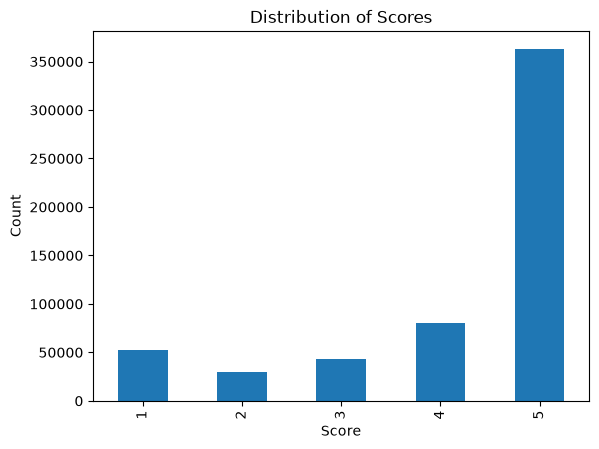

In [23]:
import matplotlib.pyplot as plt

df["Score"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Distribution of Scores")
plt.show()

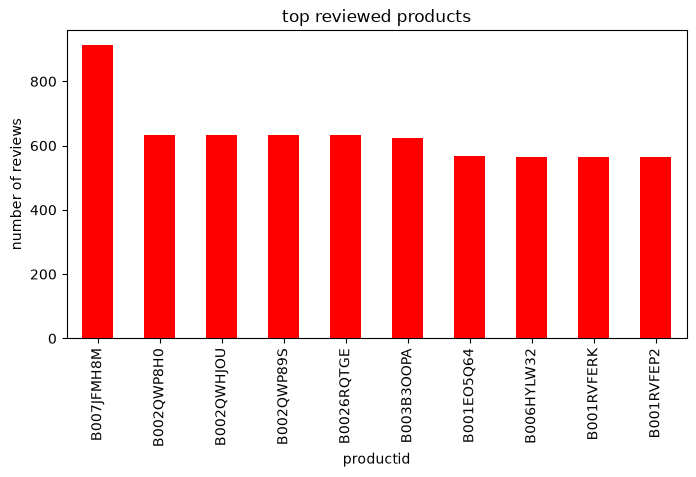

In [24]:
top_products = (df.groupby("ProductId")["Score"].count().sort_values(ascending=False).head(10))

plt.figure(figsize=(8,4))
top_products.plot(kind='bar', color="red")
plt.xlabel("productid")
plt.ylabel("number of reviews")
plt.title("top reviewed products")
plt.show()

In [25]:
avg_word_count = df.groupby("Score")["Word_Count"].mean()

print(avg_word_count)

Score
1    87.323697
2    90.040881
3    95.645755
4    91.393156
5    74.168167
Name: Word_Count, dtype: float64


Text(0.5, 1.0, 'Distribution of Average Word Counts by Score')

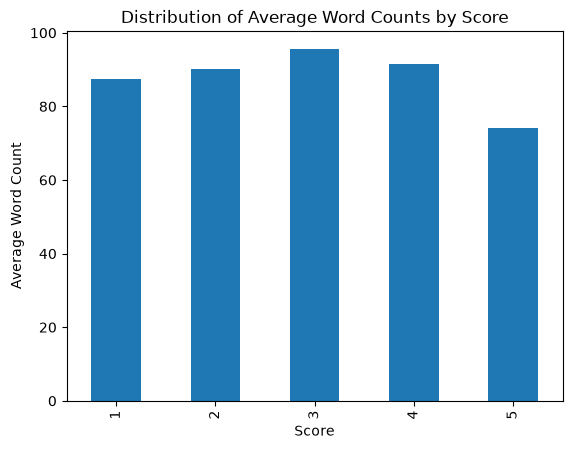

In [28]:
avg_word_count.plot(kind="bar")
plt.xlabel("Score")
plt.ylabel("Average Word Count")
plt.title("Distribution of Average Word Counts by Score")

## Review Length vs Rating

Average review length varies across ratings.

An interesting observation is that **3-star reviews are the longest on average**, while **5-star reviews are the shortest**.

This suggests that customers with mixed experiences tend to provide more detailed explanations than customers who are either highly satisfied or highly dissatisfied.

# Key Insights

From this exploratory analysis, the following observations were made:

- The dataset is clean with very few missing values.
- No completely duplicated records were found.
- Duplicate review texts appear to represent legitimate repeated customer opinions.
- Customer ratings are strongly biased toward positive reviews.
- Average review length is around **80 words**, although some reviews are significantly longer.
- Neutral (3-star) reviews contain the most detailed feedback on average.
- The engineered **Word_Count** feature will be useful for further NLP analysis and preprocessing.

These findings provide a solid foundation for building the ReviewSense AI pipeline.